In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
monthly_df = pd.read_csv(
    "data/processed/monthly_passenger_demand.csv"
)

In [3]:
monthly_df["Month"] = pd.to_datetime(monthly_df["Month"])

In [4]:
monthly_df = monthly_df.sort_values("Month").reset_index(drop=True)

In [5]:
print(monthly_df.head())
print(monthly_df.shape)

       Month  Passenger Count
0 1999-07-01          3976746
1 1999-08-01          3972694
2 1999-09-01          3341964
3 1999-10-01          3468846
4 1999-11-01          3145240
(324, 2)


In [6]:
monthly_df["Previous Month Passengers"] = (
    monthly_df["Passenger Count"].shift(1)
)

In [7]:
print(monthly_df.head(10))

       Month  Passenger Count  Previous Month Passengers
0 1999-07-01          3976746                        NaN
1 1999-08-01          3972694                  3976746.0
2 1999-09-01          3341964                  3972694.0
3 1999-10-01          3468846                  3341964.0
4 1999-11-01          3145240                  3468846.0
5 1999-12-01          3077142                  3145240.0
6 2000-01-01          2781129                  3077142.0
7 2000-02-01          2725393                  2781129.0
8 2000-03-01          3294029                  2725393.0
9 2000-04-01          3392617                  3294029.0


In [8]:
monthly_df = monthly_df.dropna().reset_index(drop=True)

In [9]:
X = monthly_df[["Previous Month Passengers"]]
y = monthly_df["Passenger Count"]

In [10]:
split_index = int(len(monthly_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [11]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 258
Testing samples: 65


In [12]:
print("Training period:")
print(monthly_df["Month"].iloc[:split_index].min(),
      "to",
      monthly_df["Month"].iloc[:split_index].max())

print("\nTesting period:")
print(monthly_df["Month"].iloc[split_index:].min(),
      "to",
      monthly_df["Month"].iloc[split_index:].max())

Training period:
1999-08-01 00:00:00 to 2021-01-01 00:00:00

Testing period:
2021-02-01 00:00:00 to 2026-06-01 00:00:00


In [13]:
model = LinearRegression()

In [14]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.94]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Previous Month Passengers']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.913e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [15]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 0.9397367228369278
Intercept: 191326.6355757364


In [16]:
y_pred = model.predict(X_test)

In [17]:
print(y_pred[:10])

[ 914837.45638167  883277.33828191 1281440.02880103 1559530.67876982
 1825548.53106033 2301542.09643825 2758696.75973345 2680833.93382607
 2465357.00196318 2739552.44321582]


In [18]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("Linear Regression MAE:", mae)

Linear Regression MAE: 322999.1017097171


In [19]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("Linear Regression RMSE:", rmse)

Linear Regression RMSE: 377807.9902267667


In [20]:
results = pd.DataFrame({
    "Model": [
        "Previous Month Baseline",
        "Linear Regression"
    ],
    "MAE": [
        326970.92307692306,
        mae
    ],
    "RMSE": [
        384439.04171943024,
        rmse
    ]
})

print(results)

                     Model            MAE           RMSE
0  Previous Month Baseline  326970.923077  384439.041719
1        Linear Regression  322999.101710  377807.990227


In [21]:
comparison = pd.DataFrame({
    "Month": monthly_df["Month"].iloc[split_index:],
    "Actual": y_test.values,
    "Predicted": y_pred
})

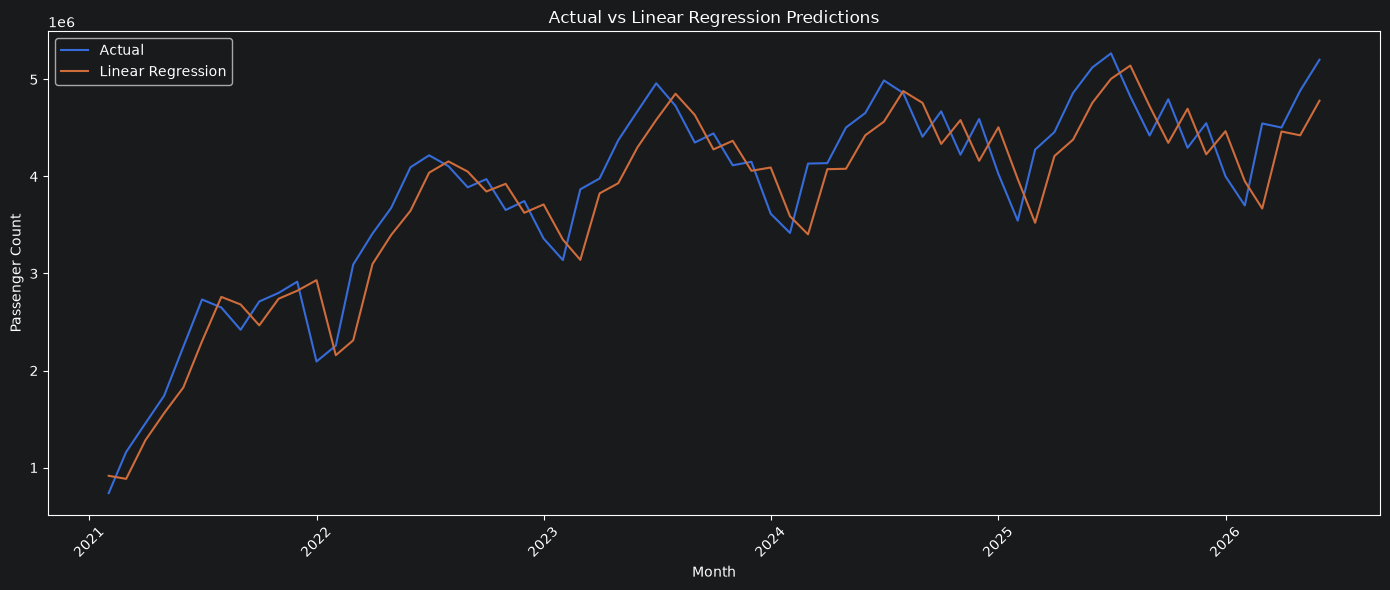

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison["Month"],
    comparison["Actual"],
    label="Actual"
)

plt.plot(
    comparison["Month"],
    comparison["Predicted"],
    label="Linear Regression"
)

plt.xlabel("Month")
plt.ylabel("Passenger Count")
plt.title("Actual vs Linear Regression Predictions")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()